In [ ]:
# Steps

# Step 1: build data pipeline -> final embeddings (token+pos+segment) embeddings (input for LLM)

# Step 2: Build Casual MHA layer -> Build FFN
# Step 3: Build Transformer Block (residual + Norm, FFN, Casual MHA)

# Step 4: Build Pre Training Pipeline on 10M Tokens

# further steps later ...


# some enhancements:

# Replace LayerNorm with RMSNorm and apply QK-Norm to stabilize attention score scaling.
# Experiments with MOE style architecture
# Optimize the attention score computation, which currently scales as O(n²), by experimenting with DeepSeek sparse attention (O(nk)) or hybrid linear–quadratic attention architectures.

In [15]:
from torch import nn

In [ ]:
# Rope

def compute_rope_params(seq_len, head_dim):
    # x: (seq_len, dim)

    device = torch.device("cpu")
    dtype = torch.float32

    assert head_dim % 2 == 0, "head_dim must be even for RoPE"
    
    theta = 1.0 / (10000 ** (torch.arange(0, head_dim, 2).float() / head_dim))

    pos = torch.arange(seq_len).float()

    angles = pos[:, None] * theta[None, :]

    
    angles = angles[None, None, :, :]

    return torch.cos(angles), torch.sin(angles)



# Similar to the style of Sebastian Raschka
def apply_rope(x, cos, sin, offset=0):

    batch_size, num_heads, seq_len, head_dim = x.shape   # (batch_size, num_heads, seq_len, head_dim)
    assert head_dim % 2 == 0, "Head dimension must be even"
    
    # split first half and second half
    x1 = x[..., : head_dim // 2]
    x2 = x[..., head_dim // 2:]


    cos_sel = cos[...,offset : offset + seq_len, :].to(x.device, x.dtype)  #(1,1,seq_len,head_dim//2)
    sin_sel = sin[..., offset : offset + seq_len, :].to(x.device, x.dtype)
    
    x_even = x[..., 0::2]  # (b,n_heads,seq_len,head_dim//2)
    x_odd  = x[..., 1::2]

    
    x_rot = torch.empty_like(x)
    
    x_rot[..., 0::2] = x_even * cos_sel - x_odd * sin_sel
    x_rot[..., 1::2] = x_even * sin_sel + x_odd * cos_sel

    return x_rot.to(dtype=x.dtype)

In [17]:
class Feedforward(nn.Module):
    def __init__(self, embedding_dim, dropout):
        super().__init__() 
        self.w1 = nn.Linear(embedding_dim, 4* embedding_dim)
        self.act = nn.ReLU()
        self.w2 = nn.Linear(4 * embedding_dim, embedding_dim)


    def forward(self, x):
        x = self.w1(x)
        x = self.act(x)
        x = self.w2(x)
        return x

In [18]:
import torch

# building LLM architecture

class grouped_head_query_attention(nn.Module):
    def __init__(self, din, dout, context_length, dropout, num_group_heads, num_heads, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads

        assert dout % num_heads == 0, f"d_out must be divisible by num_heads {dout // num_heads}"
        self.head_dim = dout // num_heads

        self.shared_group_heads = num_heads//num_group_heads

        self.num_group_heads = num_group_heads

        self.apply_rope = apply_rope

        self.wq = nn.Linear(din, dout, bias = qkv_bias)
        self.wk = nn.Linear(din, self.num_group_heads * self.head_dim, bias = qkv_bias)
        self.wv = nn.Linear(din, self.num_group_heads * self.head_dim, bias = qkv_bias)
        self.dropout = nn.Dropout(dropout)

        self.out_proj = nn.Linear(dout, din)  # Linear layer to combine head outputs

    def forward(self, x, cos, sin, start_pos):
        b, num_tokens, d_in = x.shape
        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)
        q = q.view(b, num_tokens, self.num_heads, self.head_dim)
        k = k.view(b, num_tokens, self.num_group_heads, self.head_dim)
        v = v.view(b, num_tokens, self.num_group_heads, self.head_dim)


        k = k.transpose(1,2)  # reshape to (b, num_heads, num_tokens, head_dim)
        v = v.transpose(1,2)  # reshape to (b, n_group_heads, num_tokens, head_dim)
        q = q.transpose(1,2)


        q_enc = self.apply_rope(q, cos, sin, start_pos)
        k_enc = self.apply_rope(k, cos, sin, start_pos)

        k_new = k_enc.repeat_interleave(self.shared_group_heads, dim=1)
        v_new = v.repeat_interleave(self.shared_group_heads, dim=1)
        
        attn_scores = q_enc @ k_new.transpose(2,3)

        # Move the mask to the same device as attn_scores
        mask = torch.triu(torch.ones(num_tokens, num_tokens), diagonal=1).to(x.device)
        
        attn_scores = attn_scores / (self.head_dim ** 0.5)
        attn_scores = attn_scores.masked_fill(mask.bool(), -torch.inf)
        attn_weights = torch.softmax(attn_scores, dim=-1)
        
        attn_weights = self.dropout(attn_weights)

        z = (attn_weights @ v_new)

       # Reshape and project
        z = z.transpose(1, 2).contiguous()  # Reshape to (b, num_tokens, num_heads, head_dim)
        z = z.view(b, num_tokens, -1)  # Reshape to (b, num_tokens, dout)
        z = self.out_proj(z)  # Project to output dimension

        return z

In [19]:
class TransformerBlock(nn.Module):
    def __init__(self, embedding_dim, new_feature_dim, context_length, dropout, num_heads, num_group_heads, qkv_bias=False):
        super().__init__()
        self.mha = grouped_head_query_attention(embedding_dim, new_feature_dim, context_length, 
                                                    dropout, num_group_heads, num_heads, qkv_bias=False)
        self.feedforward = Feedforward(embedding_dim, dropout)
        self.layernorm = nn.LayerNorm(embedding_dim)
        self.dropout = nn.Dropout(dropout)


    def forward(self, x, cos, sin, start_pos):

        x1 = self.layernorm(x)
        x1 = self.mha(x1, cos, sin, start_pos)
        x = x + self.dropout(x1)

        x2 = self.layernorm(x)
        x2 = self.feedforward(x2)
        x = x + self.dropout(x2)
        return x

In [20]:

import torch

class Embedding(nn.Module):
  """
  Returns:
      _type_: return emeding vecotrs
  """
  def __init__(self, vocab_size, embedding_dim):
      super().__init__()
      self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
      # self.position_embedding = nn.Embedding(max_position_seq_len, embedding_dim)  # embedding dim or hidden_size =768
      # self.segment_embedding = nn.Embedding(2, embedding_dim)
    
  def forward(self, input_ids):
      B, T = input_ids.shape

      # pos_ids = torch.arange(T, device=input_ids.device).unsqueeze(0).expand(B, T)
      # seg_ids = torch.zeros((B, T), dtype=torch.long, device=input_ids.device)

      # x = (
      #     self.token_embedding(input_ids) +
      #     self.position_embedding(pos_ids) +
      #     self.segment_embedding(seg_ids)
      # )

      x = self.token_embedding(input_ids)
      return x   # shape (B, T, embedding_dim)


In [21]:
class LocalLLM(nn.Module):
  # embedding_dim == new_feature_dim
  def __init__(self, embedding_dim, vocab_size, new_feature_dim, context_length, dropout, num_heads, 
               n_transformer, num_group_heads, qkv_bias=False):
      
    super().__init__()
    self.preprocessing = Embedding(vocab_size, embedding_dim)
    self.decoder_stack = nn.ModuleList([TransformerBlock(embedding_dim, 
                                                         new_feature_dim, context_length, 
                                                         dropout, num_heads, 
                                                         num_group_heads) 
                                        for _ in range(n_transformer)]) # Removed the '*' here

    cos, sin = compute_rope_params(context_length, embedding_dim//num_heads) 

    # register so they move with the model and are saved in state_dict
    self.register_buffer("rope_cos", cos)
    self.register_buffer("rope_sin", sin)

    self.cos, self.sin = cos, sin
    
    self.final_norm = nn.LayerNorm(embedding_dim)
    self.out_head = nn.Linear(
        embedding_dim, vocab_size, bias=False
    )


  def forward(self, inputs, start_pos: int = 0):
    x = self.preprocessing(inputs)
    for layer in self.decoder_stack:
      x = layer(x, self.cos, self.sin, start_pos)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits


In [22]:
# for batch in train_loader:
#     print(f"Input IDs shape: {batch['input_ids'].shape}")
#     print(f"Labels shape: {batch['labels'].shape}")
#     print(f"Attention Mask shape: {batch['attention_mask'].shape}")
#     break

In [23]:
# Custom Tokenizer


from transformers import PreTrainedTokenizerFast

tokenizer = PreTrainedTokenizerFast(tokenizer_file="/kaggle/input/datasets/eiann1509/my-gpt-tokenizer/my_gpt_tokenizer.json",
                                    eos_token="<|endoftext|>")

print(tokenizer("Hello world"))

{'input_ids': [40, 15570, 857], 'token_type_ids': [0, 0, 0], 'attention_mask': [1, 1, 1]}


In [24]:
tokenizer.vocab_size

20000

In [25]:
len(tokenizer)

20000

In [26]:

embedding_dim = 512
vocab_size = tokenizer.vocab_size  # Use the actual vocabulary size of the tokenizer
new_feature_dim = 512  # embedding_dim -new_feature_dim as din == dout anas output needs to have same dim before it was from transformer block
context_length = 256
dropout = 0.1
num_heads = 8
n_transformer = 6
num_group_heads = 4



llm = LocalLLM(embedding_dim, vocab_size, new_feature_dim, context_length, dropout, 
               num_heads, n_transformer, num_group_heads)

In [27]:
vocab_size

20000

In [28]:
total_params = sum(p.numel() for p in llm.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 37807104


In [29]:
# import numpy as np

# path = "/kaggle/input/fineweb-tokens-dataset-memmap-type/fineweb_tokens.memmap"

# # IMPORTANT: dtype must match how it was created
# tokens = np.memmap(
#     path,
#     dtype=np.int32,   # or np.int64 — see note below
#     mode="r"
# )

# print(type(tokens))
# print(tokens.shape)
# print(tokens[:20])

In [30]:
# import os, torch, torch.distributed as dist, torch.multiprocessing as mp
# from torch.nn.parallel import DistributedDataParallel as DDP
# from torch.utils.data.distributed import DistributedSampler

# def ddp_setup(rank, world_size):
#     os.environ["MASTER_ADDR"] = "localhost"
#     os.environ["MASTER_PORT"] = "29500"
#     dist.init_process_group("nccl", rank=rank, world_size=world_size)
#     torch.cuda.set_device(rank)

In [31]:
# def main_worker(rank, world_size):
#     setup_ddp(rank, world_size)

#     device = torch.device("cuda", rank)

In [32]:
# world_size = torch.cuda.device_count()
# mp.spawn(main_worker, args=(world_size,), nprocs=world_size)

In [33]:
# pre training on 250M tokens
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
import torch
# from torch.utils.data.distributed import DistributedSampler

import numpy as np


class LLMDataset(Dataset):
    def __init__(self, path, tokenizer, context_length):

        # self.tokenizer = tokenizer
        self.path = path
        self.context_length = context_length  # Store max_len for use in __getitem__
    
        # Use memmap to avoid loading the full token dataset into RAM.
        # The file is memory-mapped: data remains on disk and the OS loads only the accessed pages
        # into the page cache when slices are requested. Python only holds views to this data through pointers,
        # not full copies, keeping memory usage low and stable across iterations.
          
        self.lst_token_ids = None
    
        # self.lst_token_ids = []
        # with open(path, 'r', encoding="utf-8") as f:
        #     for line in f:
        #         ids = tokenizer.encode(line)
    
        #         token_ids = torch.tensor(ids, dtype=torch.long)
    
        #         self.lst_token_ids.extend(token_ids.tolist())
    
    
        # torch.save(self.lst_token_ids, "/kaggle/working/fineweb_tokens_latest_20k_vocab.pt")

    def _lazy_init(self):                         
        if self.lst_token_ids is None:
            self.lst_token_ids = np.memmap(self.path, dtype=np.int32, mode="r")

      
    def __len__(self):
        self._lazy_init()
    
        MAX_TOKENS = 250_000_000
        usable_tokens = min(len(self.lst_token_ids), MAX_TOKENS)
    
        if usable_tokens < self.context_length + 1:
            return 0
    
        return (usable_tokens - (self.context_length + 1)) // self.context_length

    def __getitem__(self, idx):
        self._lazy_init()

        index = idx * self.context_length

        inp_ids = self.lst_token_ids[index : index + self.context_length]
        lbl_ids = self.lst_token_ids[index + 1 : index + self.context_length + 1]

        assert len(inp_ids) == len(lbl_ids) == self.context_length

        
        return {
            "input_ids": torch.tensor(inp_ids, dtype=torch.long),
            "labels": torch.tensor(lbl_ids, dtype=torch.long),
            "attention_mask": torch.ones(self.context_length, dtype=torch.long),
        }



llm_dataset = LLMDataset("/kaggle/input/datasets/eiann1509/fineweb-tokens-latest-20k-vocab-memmap/fineweb_tokens_latest_20k_vocab.memmap", 
                         tokenizer, context_length)

# sampler = DistributedSampler(llm_dataset)

train_loader = DataLoader(
    llm_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

In [34]:
print(len(train_loader))

30518


In [35]:
# # loss_func: crossentropy:

# import math


# def lm_loss(outputs, labels):
#     """
#     outputs: (B, T, V) logits
#     labels: (B, T) integer token indices
#     returns: mean loss (scalar) and per-token loss tensor (B, T)
#     """

#     B, T, V = outputs.shape

#     # Compute softmax probs per token
#     probs = torch.softmax(outputs, dim=-1)  # (B, T, V)

#     per_token_loss = torch.zeros(B, T)      # store each token's CE

#     for b in range(B):
#         for t in range(T):
#             correct_idx = labels[b][t]
#             per_token_loss[b, t] = -torch.log(probs[b, t, correct_idx] + 1e-12)  # avoid log(0)

#     mean_loss = per_token_loss.mean()

#     return mean_loss

In [36]:
# import torch
# import numpy as np

# tokens = torch.load("/kaggle/working/fineweb_tokens_latest_20k_vocab.pt")
# print("Number of tokens:", len(tokens))

In [37]:
# # gpt code

# memmap_path = "/kaggle/working/fineweb_tokens_latest_20k_vocab.memmap"

# N = len(tokens)

# mm = np.memmap(
#     memmap_path,
#     dtype=np.int32,
#     mode="w+",
#     shape=(N,)
# )

# mm[:] = np.array(tokens, dtype=np.int32)
# mm.flush()


# tokens = np.memmap(
#     "/kaggle/working/fineweb_tokens_latest_20k_vocab.memmap",
#     dtype=np.int32,
#     mode="r"
# )

# print("Number of tokens:", len(tokens))

In [38]:
# loss_func: crossentropy:

import math
import torch.nn.functional as F


def lm_loss(outputs, labels):
    """
    outputs: (B, T, V) logits
    labels: (B, T) integer token indices
    returns: mean loss (scalar)
    """

    B, T, V = outputs.shape

    # 1. Flatten batch and time
    logits  = outputs.view(B * T, V)     # (B*T, V)
    targets = labels.view(B * T)          # (B*T)

    # 2. Log-softmax (numerically stable)
    log_probs = F.log_softmax(logits, dim=-1)  # (B*T, V)

    # 3. Pick correct class per token
    loss = -log_probs[torch.arange(B * T), targets]  # (B*T)

    # 4. Mean loss
    mean_loss = loss.mean()

    return mean_loss



In [39]:
def save_checkpoint(model, optimizer, scheduler, scaler, epoch, step, epoch_losses, 
                    step_losses_to_save, path="/kaggle/working/latest_model_checkpoint_new_v8.pt"):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "epoch": epoch,
        "step": step,
        "epoch_losses": epoch_losses,
        "step_losses_to_save": step_losses_to_save
    }
    torch.save(checkpoint, path)
    print(f"Checkpoint saved at epoch {epoch}, step {step}")

def load_checkpoint(llm, optimizer, scheduler, scaler,
                    path="/kaggle/input/models/eiann1509/latest-model-checkpoint-new-v6/pytorch/default/1/latest_model_checkpoint_new_v6.pt", device="cuda", epoch_losses=None, step_losses_to_load=None):

    if epoch_losses is None:
        epoch_losses = []
    if step_losses_to_load is None:
        step_losses_to_load = []

    checkpoint = torch.load(path, map_location="cpu")

    llm.load_state_dict(checkpoint["model_state_dict"])
    llm.to(device)

    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    if "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    epoch = checkpoint.get("epoch", 0)
    overall_step = checkpoint.get("step", 0)

    if "epoch_losses" in checkpoint:
        epoch_losses.extend(checkpoint["epoch_losses"])
    if "step_losses_to_save" in checkpoint:
        step_losses_to_load.extend(checkpoint["step_losses_to_save"])

    llm.train()

    print(f"Resuming from epoch {epoch}, overall step {overall_step}")
    return epoch, overall_step, epoch_losses, step_losses_to_load

In [40]:
print(len(train_loader))

30518


In [41]:
def plot(current_session_dense_losses):
    if current_session_dense_losses:
        epoch, steps, losses = zip(*current_session_dense_losses)
        plt.figure(figsize=(12, 6))
        plt.plot(steps, losses, marker='.', linestyle='-') # Use '.' for many points
        plt.title('Training Batch Loss (First 50 Steps of Current Session)')
        plt.xlabel('Current Step')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.show()
    else:
        print("No dense batch losses to plot for the first 5 steps of this session. Ensure training ran and cuurent_step reached <= 50.")


In [42]:
# epochs = 5
# batch_size = 8  # if memory allows
# peak_lr = 5e-5
# warmup_steps = 200  # just 100–500 steps for tiny model
# total_steps = epochs * len(train_loader)
# total_steps


warmup_steps:  1831


/tmp/ipykernel_55/3287368106.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this

Batch loss: 5.6444 | lr: 9.464741153618782e-05 | epoch_step: 5000
Epoch 1/2 after 5000 steps, Average Mid Loss: 6.4476, time_taken_for_5k_steps 973.644065618515
Throughput: 5.14 steps/sec and total time taken is: 973.644065618515
Batch loss: 5.0739 | lr: 8.620217887002788e-05 | epoch_step: 10000
Epoch 1/2 after 10000 steps, Average Mid Loss: 5.9318, time_taken_for_5k_steps 976.7948215007782
Throughput: 5.12 steps/sec and total time taken is: 976.7948215007782
Batch loss: 5.1098 | lr: 7.775694620386792e-05 | epoch_step: 15000
Epoch 1/2 after 15000 steps, Average Mid Loss: 5.6676, time_taken_for_5k_steps 976.2903218269348
Throughput: 5.12 steps/sec and total time taken is: 976.2903218269348
Batch loss: 5.2274 | lr: 6.931171353770796e-05 | epoch_step: 20000
Epoch 1/2 after 20000 steps, Average Mid Loss: 5.4961, time_taken_for_5k_steps 974.4195923805237
Throughput: 5.13 steps/sec and total time taken is: 974.4195923805237
Batch loss: 4.6463 | lr: 6.0866480871548015e-05 | epoch_step: 25000


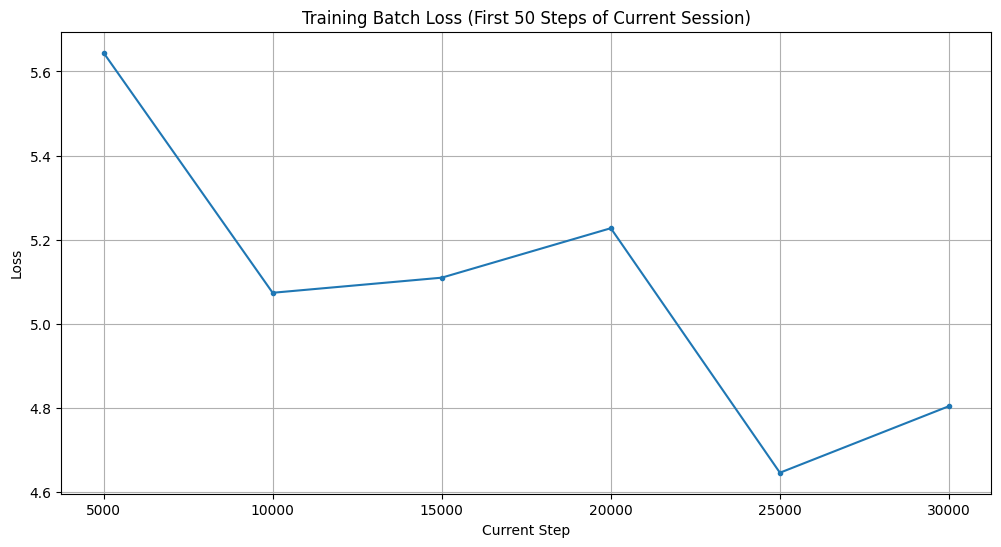



Epoch 1/2, Average Loss: 5.2739
Batch loss: 4.7118 | lr: 4.310108943501394e-05 | epoch_step: 5000
Epoch 2/2 after 5000 steps, Average Mid Loss: 4.7241, time_taken_for_5k_steps 972.1492915153503
Throughput: 5.14 steps/sec and total time taken is: 972.1492915153503
Batch loss: 4.5378 | lr: 3.465585676885398e-05 | epoch_step: 10000
Epoch 2/2 after 10000 steps, Average Mid Loss: 4.6915, time_taken_for_5k_steps 972.5324146747589
Throughput: 5.14 steps/sec and total time taken is: 972.5324146747589
Batch loss: 4.6299 | lr: 2.6210624102694032e-05 | epoch_step: 15000
Epoch 2/2 after 15000 steps, Average Mid Loss: 4.6654, time_taken_for_5k_steps 973.6371607780457
Throughput: 5.14 steps/sec and total time taken is: 973.6371607780457
Batch loss: 4.9054 | lr: 1.7765391436534075e-05 | epoch_step: 20000
Epoch 2/2 after 20000 steps, Average Mid Loss: 4.6438, time_taken_for_5k_steps 972.9200253486633
Throughput: 5.14 steps/sec and total time taken is: 972.9200253486633
Batch loss: 4.3697 | lr: 9.320

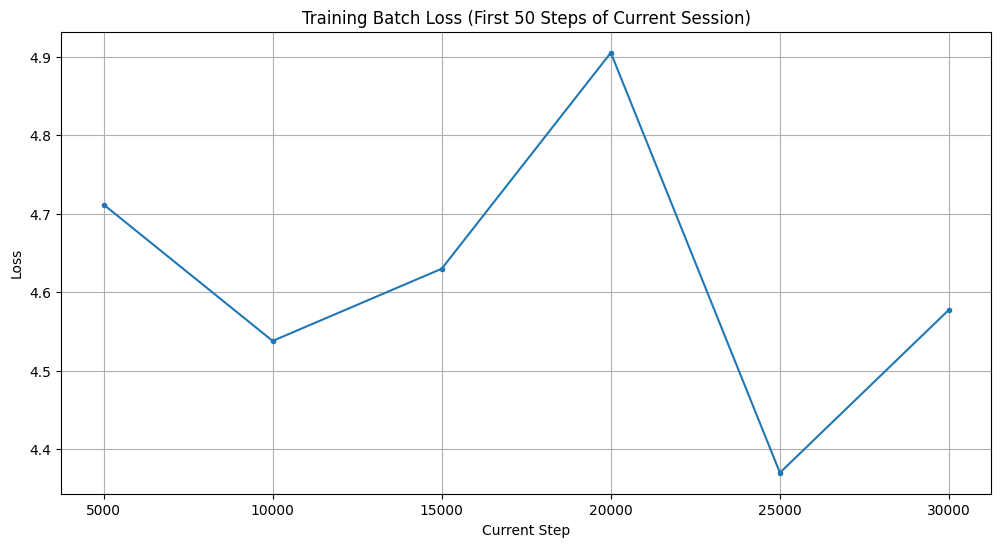



Epoch 2/2, Average Loss: 4.6193


In [30]:
import torch.optim as optim
from transformers import get_linear_schedule_with_warmup
import torch.cuda.amp as amp
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# local_rank = setup_ddp()
# device = torch.device("cuda", local_rank)

llm = llm.to(device)  # move model to gpu
# llm = torch.nn.parallel.DistributedDataParallel(llm, device_ids=[local_rank])

learning_rate = 1e-4  # peak_lr
optimizer = optim.AdamW(llm.parameters(), lr=learning_rate, betas=(0.9,0.95), eps=1e-8, weight_decay=0.01)

start_epoch = 1
num_epochs = 2

# Initialize GradScaler for mixed precision training
scaler = amp.GradScaler()


total_steps = num_epochs * len(train_loader)
warmup_steps = int(0.03 * total_steps)  # 3% warmup
print('warmup_steps: ', warmup_steps)


start_step = 0

epoch_losses = [] # Initialize an empty list to store average losses per epoch
# plot_step_losses = [] # Initialize an empty list to store losses at specific steps for plotting (saved in checkpoint)
current_session_dense_losses = [] # NEW: Initialize a list to store all batch losses up to 5000 steps for the current session's plot

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# last_epoch, last_overall_step, epoch_losses, plot_step_losses = load_checkpoint(llm, optimizer, scheduler, scaler)

# print(last_overall_step)  # ttoal steps completed in epochs completed
# save_every_n_steps = 5000 # adjust based on memory & time

# checkpoint_flag = False
last_overall_step = 0
last_epoch=0
current_epoch = last_epoch + 1

lr = None

for epoch in range(current_epoch, num_epochs+1):
    llm.train()

    total_loss = 0
    current_step =0
    
    torch.cuda.synchronize()
    st_time = time.time()
    
    for batch_idx, batch in enumerate(train_loader):

        current_step += 1
        last_overall_step += 1   # THIS IS REQUIRED

        optimizer.zero_grad()

        # move batch data to GPU
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)

        # Use autocast for mixed precision
        with amp.autocast():
            outputs = llm(input_ids)  # shape : (b, t, v)
            loss = lm_loss(outputs, labels)

        # Scale the loss and call backward() to create scaled gradients
        scaler.scale(loss).backward()

        # Unscales the gradients of optimizer's assigned parameters in-place
        # If enable=False or not run, gradients are not unscaled, and are expected to be float32
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(llm.parameters(), max_norm=1.0)

        # After Unscaling gradients and call optimizer.step()
        # If gradients are non-finite, engine will skip optimizer.step() and clear grads
        
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        lr = optimizer.param_groups[0]["lr"]

        total_loss += loss.item()
        # print(
        #     f"Batch loss: {loss.item():.4f} | "
        #     f"lr: {lr if lr is not None else 'SKIPPED'} | "
        #     f"epoch_step: {current_step}"
        # )
        if current_step%5000 == 0:
            torch.cuda.synchronize()
            end_time = time.time()
            
            print(
                f"Batch loss: {loss.item():.4f} | "
                f"lr: {lr if lr is not None else 'SKIPPED'} | "
                f"epoch_step: {current_step}"
            )

            avg_mid_epoch_loss = total_loss / current_step
            
            print(f"Epoch {epoch}/{num_epochs} after {current_step} steps, Average Mid Loss: {avg_mid_epoch_loss:.4f}, time_taken_for_5k_steps {end_time - st_time}")
            
            current_session_dense_losses.append((epoch, current_step, avg_mid_epoch_loss))


            
            steps_per_sec = 5000 / (end_time - st_time)
            print(f"Throughput: {steps_per_sec:.2f} steps/sec and total time taken is: {end_time - st_time}")
            
            torch.cuda.synchronize()
            st_time = time.time()

        
    avg_epoch_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_epoch_loss)
    
    save_checkpoint(llm, optimizer, scheduler, scaler, epoch, last_overall_step, epoch_losses, current_session_dense_losses)
    plot(current_session_dense_losses)
    current_session_dense_losses = []

     # Store the average loss for the epoch
    print('\n')
    print(f"Epoch {epoch}/{num_epochs}, Average Loss: {avg_epoch_loss:.4f}")




In [2]:
import torch

epoch_losses = [5.27, 4.61]

for epoch, loss in enumerate(epoch_losses):
    perplexity = torch.exp(torch.tensor(loss))
    print(f"Epoch {epoch+1}: PPL = {perplexity.item():.3f}")

Epoch 1: PPL = 194.416
Epoch 2: PPL = 100.484


In [ ]:

# start_epoch = 1
# num_epochs = 15


# start_step = 2345
# for epoch in range(start_epoch, num_epochs):
#     total_loss = 0
#     global_step = 0
#     for batch_idx in range(3647):


#         global_step += 1 # Increment global_step for each batch

#         if global_step <= start_step:
#             continue  # skip already trained steps

#         print('yes', global_step)
#         break

In [ ]:
# avg_epoch_loss = total_loss / len(train_loader)
# epoch_losses.append(avg_epoch_loss)

# save_checkpoint(llm, optimizer, scheduler, scaler, epoch, last_overall_step, epoch_losses, current_session_dense_losses)
# plot(current_session_dense_losses)
# current_session_dense_losses = []

#  # Store the average loss for the epoch
# print('\n')
# print(f"Epoch {epoch}/{num_epochs}, Average Loss: {avg_epoch_loss:.4f}")

In [31]:
# print(start_epoch, start_step, epoch_losses)


1 0 [5.273854904573549, 4.619328924131328]


In [32]:
print("Optimizer LR:", optimizer.param_groups[0]["lr"])
print("Scheduler last_epoch:", scheduler.last_epoch)

Optimizer LR: 0.0
Scheduler last_epoch: 61036


In [33]:
for batch_idx, batch in enumerate(train_loader):

    input_ids = batch['input_ids'].to(device, non_blocking=True)

    token_ids = input_ids[0].tolist()   # shape [T]
    text = tokenizer.decode(token_ids)
    print(text)
    outputs = llm(input_ids)  # shape : (b, t, v)

    break

Discover the cosmos! Each day a different image or photograph of our fascinating universe is featured, along with a brief explanation written by a professional astronomer. 2012 June 23 Explanation: As seen from Frösön island in northern Sweden the Sun did set a day after the summer solstice. From that location below the arctic circle it settled slowly behind the northern horizon. During the sunset's final minute, this remarkable sequence of 7 images follows the distorted edge of the solar disk as it just disappears against a distant tree line, capturing both a green and blue flash. Not a myth even in a land of runes, the colorful but elusive glints are caused by atmospheric refraction enhanced by long, low, sight lines and strong atmospheric temperature gradients. Authors & editors: Jerry Bonnell (UMCP) NASA Official: Phillip Newman Specific rights apply. A service of: ASD at NASA / GSFC & Michigan Tech. U.
ASL Literature and Art This section is a collection of ASL storytelling, poetry

In [34]:
outputs.shape

torch.Size([32, 256, 20000])

In [35]:

logits = outputs
next_logits = logits[:, -1, :]          # last timestep
next_token = torch.argmax(next_logits, dim=-1, keepdim=True)

generated = torch.cat([input_ids, next_token], dim=1)

In [36]:
decoded_text = tokenizer.decode(generated[0].tolist()) 
decoded_text

"Discover the cosmos! Each day a different image or photograph of our fascinating universe is featured, along with a brief explanation written by a professional astronomer. 2012 June 23 Explanation: As seen from Frösön island in northern Sweden the Sun did set a day after the summer solstice. From that location below the arctic circle it settled slowly behind the northern horizon. During the sunset's final minute, this remarkable sequence of 7 images follows the distorted edge of the solar disk as it just disappears against a distant tree line, capturing both a green and blue flash. Not a myth even in a land of runes, the colorful but elusive glints are caused by atmospheric refraction enhanced by long, low, sight lines and strong atmospheric temperature gradients. Authors & editors: Jerry Bonnell (UMCP) NASA Official: Phillip Newman Specific rights apply. A service of: ASD at NASA / GSFC & Michigan Tech. U.\nASL Literature and Art This section is a collection of ASL storytelling, poet

In [37]:
# import torch

# ckpt = torch.load("/kaggle/input/models/eiann1509/latest-model-checkpoint-new-v7/pytorch/default/1/latest_model_checkpoint_new_v7.pt", map_location="cpu")
# print(type(ckpt))

In [38]:
# ckpt.keys()

In [39]:

# from safetensors.torch import save_file
# # Extract ONLY model weights
# state_dict = ckpt["model_state_dict"]

# # Save as safetensors
# save_file(state_dict, "pre_trained_model.safetensors")

# print("Conversion successful.")

# **Hugginface wrapper**

In [70]:
from transformers import PretrainedConfig

class LocalLLMConfig(PretrainedConfig):
    model_type = "localllm"

    def __init__(
        self,
        embedding_dim=512,
        vocab_size=32000,
        new_feature_dim=512,
        context_length=1024,
        dropout=0.1,
        num_heads=8,
        n_transformer=8,
        num_group_heads=8,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.embedding_dim = embedding_dim
        self.vocab_size = vocab_size
        self.new_feature_dim = new_feature_dim
        self.context_length = context_length
        self.dropout = dropout
        self.num_heads = num_heads
        self.n_transformer = n_transformer
        self.num_group_heads = num_group_heads

In [71]:
import torch
from transformers import PreTrainedModel


class LocalLLMForCausalLM(PreTrainedModel):
    config_class = LocalLLMConfig

    def __init__(self, config):
        super().__init__(config)

        self.model = LocalLLM(
            embedding_dim=config.embedding_dim,
            vocab_size=config.vocab_size,
            new_feature_dim=config.new_feature_dim,
            context_length=config.context_length,
            dropout=config.dropout,
            num_heads=config.num_heads,
            n_transformer=config.n_transformer,
            num_group_heads=config.num_group_heads,
        )

        self.post_init()

    def forward(self, input_ids, **kwargs):
        return self.model(input_ids)

### Comparison between 53M model vs 37M model

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import math
import tiktoken
from transformers import AutoTokenizer

def fix_state_dict(sd):
    new_sd = {}
    for k, v in sd.items():
        new_sd["model." + k] = v
    return new_sd
    
# -------------------------
# DEVICE
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# LOAD MODELS
# -------------------------

config_37 = LocalLLMConfig(
    embedding_dim=512,
    vocab_size=20000,
    context_length=256,
    num_heads=8,
    n_transformer=6,
    num_group_heads=4,
    dropout=0.1
)

config_53 = LocalLLMConfig(
    embedding_dim=256,
    new_feature_dim=256,
    vocab_size=100277,
    context_length=128,
    num_heads=8,
    n_transformer=3,
    num_group_heads=2,
    dropout=0.1
)

model_37M = LocalLLMForCausalLM(config_37)
model_53M = LocalLLMForCausalLM(config_53)

state_dict_37 = torch.load(
    "/kaggle/input/models/eiann1509/latest-model-checkpoint-new-v8-37m-model/pytorch/default/1/latest_model_checkpoint_new_v8.pt",
    map_location="cpu"
)

state_dict_53 = torch.load(
    "/kaggle/input/models/eiann1509/latest-model-checkpoint-new-v7/pytorch/default/1/latest_model_checkpoint_new_v7.pt",
    map_location="cpu"
)

sd_37 = fix_state_dict(state_dict_37["model_state_dict"])
sd_53 = fix_state_dict(state_dict_53["model_state_dict"])

model_37M.load_state_dict(sd_37)
model_53M.load_state_dict(sd_53)

model_37M.to(device)
model_53M.to(device)

# -------------------------
# TOKENIZERS
# -------------------------

tokenizer_37 = AutoTokenizer.from_pretrained(
    "zyberg2091/fineweb_pretrained_model_37M"
)

tokenizer_53 = tiktoken.get_encoding("cl100k_base")

PAD_ID_37 = 0
PAD_ID_53 = 0

# -------------------------
# DATASET
# -------------------------

dataset = load_dataset("wikitext", "wikitext-2-raw-v1")
val_texts = dataset["validation"]["text"]

val_texts = [t for t in val_texts if len(t.strip()) > 0]

# 🔥 FIX: token-based sampling instead of fixed 2000
max_tokens = 200000
current_tokens = 0
filtered = []

for t in val_texts:
    tokens = tokenizer_37.encode(t)
    current_tokens += len(tokens)
    filtered.append(t)
    if current_tokens >= max_tokens:
        break

val_texts = filtered

print(f"Using ~{current_tokens} tokens for evaluation")

# -------------------------
# DATASETS
# -------------------------

class Dataset37(Dataset):
    def __init__(self, texts, tokenizer, max_length):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = self.tokenizer.encode(text)

        tokens = tokens[:self.max_length]

        if len(tokens) < self.max_length:
            tokens += [PAD_ID_37] * (self.max_length - len(tokens))

        return {
            "input_ids": torch.tensor(tokens, dtype=torch.long),
        }


class Dataset53(Dataset):
    def __init__(self, texts, tokenizer, max_length):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = self.tokenizer.encode(text)

        tokens = tokens[:self.max_length]

        if len(tokens) < self.max_length:
            tokens += [PAD_ID_53] * (self.max_length - len(tokens))

        return {
            "input_ids": torch.tensor(tokens, dtype=torch.long),
        }

# -------------------------
# LOADERS
# -------------------------

val_loader_37 = DataLoader(Dataset37(val_texts, tokenizer_37, 256), batch_size=8)
val_loader_53 = DataLoader(Dataset53(val_texts, tokenizer_53, 128), batch_size=8)

# -------------------------
# VALIDATION
# -------------------------

def validate(model, loader, pad_id):
    model.eval()

    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)

            inputs = input_ids[:, :-1]
            targets = input_ids[:, 1:]

            outputs = model(inputs)
            logits = outputs["logits"] if isinstance(outputs, dict) else outputs

            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1),
                reduction="sum",
                ignore_index=pad_id
            )

            total_loss += loss.item()
            total_tokens += (targets != pad_id).sum().item()

    avg_loss = total_loss / total_tokens
    ppl = math.exp(avg_loss)
    bpb = avg_loss / math.log(2)

    print(f"Total tokens evaluated: {total_tokens}")

    return avg_loss, ppl, bpb

# -------------------------
# RUN
# -------------------------

loss_37, ppl_37, bpb_37 = validate(model_37M, val_loader_37, PAD_ID_37)
loss_53, ppl_53, bpb_53 = validate(model_53M, val_loader_53, PAD_ID_53)

print("\n===== RESULTS =====")
print(f"37M -> Loss: {loss_37:.4f}, PPL: {ppl_37:.2f}, BPB: {bpb_37:.4f}")
print(f"53M -> Loss: {loss_53:.4f}, PPL: {ppl_53:.2f}, BPB: {bpb_53:.4f}")

In [72]:
embedding_dim = 512
vocab_size = tokenizer.vocab_size  # Use the actual vocabulary size of the tokenizer
new_feature_dim = 512  # embedding_dim -new_feature_dim as din == dout anas output needs to have same dim before it was from transformer block
context_length = 256
dropout = 0.1
num_heads = 8
n_transformer = 6
num_group_heads = 4

### Export model

In [73]:
len(tokenizer)

20000

In [74]:
import torch

config = LocalLLMConfig(
    embedding_dim,
    vocab_size,
    new_feature_dim,
    context_length,
    dropout,
    num_heads,
    n_transformer,
    num_group_heads,
)

model = LocalLLMForCausalLM(config)

checkpoint = torch.load("/kaggle/input/models/eiann1509/latest-model-checkpoint-new-v8-37m-model/pytorch/default/1/latest_model_checkpoint_new_v8.pt", map_location="cpu")

state_dict = checkpoint["model_state_dict"]

# Add "model." prefix
new_state_dict = {
    "model." + k: v
    for k, v in state_dict.items()
}

model.load_state_dict(new_state_dict)

# model.save_pretrained("fineweb_pretarined_model")

<All keys matched successfully>

In [44]:
model.save_pretrained("fineweb_pretrained_model_37M")

In [45]:
import json

with open("fineweb_pretrained_model_37M/config.json") as f:
    config = json.load(f)

print(config)

{'architectures': ['LocalLLMForCausalLM'], 'context_length': 256, 'dropout': 0.1, 'dtype': 'float32', 'embedding_dim': 512, 'model_type': 'localllm', 'n_transformer': 6, 'new_feature_dim': 512, 'num_group_heads': 4, 'num_heads': 8, 'transformers_version': '4.57.1', 'vocab_size': 20000}


In [ ]:
# import tiktoken
# from transformers import PreTrainedTokenizer

# class LocalLLMTokenizer(PreTrainedTokenizer):
#     model_input_names = ["input_ids"]

#     def __init__(self, **kwargs):
#         super().__init__(**kwargs)
#         self.encoding = tiktoken.get_encoding("cl100k_base")

#     @property
#     def vocab_size(self):
#         return self.encoding.n_vocab

#     def _tokenize(self, text):
#         return self.encoding.encode(text)

#     def _convert_token_to_id(self, token):
#         return token

#     def _convert_id_to_token(self, index):
#         return index

#     def encode(self, text, **kwargs):
#         return self.encoding.encode(text)

#     def decode(self, token_ids, **kwargs):
#         return self.encoding.decode(token_ids)

In [47]:
!zip -r fineweb_pretrained_model_37M.zip /kaggle/working/fineweb_pretrained_model_37M

  adding: kaggle/working/fineweb_pretrained_model_37M/ (stored 0%)
  adding: kaggle/working/fineweb_pretrained_model_37M/config.json (deflated 35%)
  adding: kaggle/working/fineweb_pretrained_model_37M/model.safetensors

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 7%)


In [48]:
from IPython.display import FileLink
FileLink(r'fineweb_pretrained_model_37M.zip')

/kaggle/working/fineweb_pretrained_model_37M.zip

In [82]:
import shutil

shutil.rmtree('/kaggle/working/tokenizer')

### TOKENIZER TRAINING 

In [ ]:
import logging
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

# 1. Create empty BPE tokenizer
tokenizer = Tokenizer(BPE(unk_token=None))

logging.basicConfig(level=logging.INFO)

# 2. Use byte-level pre-tokenizer (GPT-style)
tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False)

tokenizer.decoder = ByteLevelDecoder()

# 3. Setup trainer
trainer = BpeTrainer(
    vocab_size=20000,                 # your desired vocab size
    special_tokens = ["<|endoftext|>"],
    show_progress=True   # IMPORTANT
)

# 4. Train on your text files
files = ["/kaggle/input/fineweb-edu-500m-tokens/fineweb_edu_slice_500M.txt"]  # put your training text file here
tokenizer.train(files, trainer)

# 5. Save tokenizer
tokenizer.save("/kaggle/working/my_gpt_tokenizer.json")

print("Training complete!")

In [83]:
from transformers import PreTrainedTokenizerFast

tokenizer = PreTrainedTokenizerFast(tokenizer_file="/kaggle/input/datasets/eiann1509/my-gpt-tokenizer/my_gpt_tokenizer.json")

In [84]:
print("token id:", tokenizer.convert_tokens_to_ids("<|endoftext|>"))
print("token:", tokenizer.convert_ids_to_tokens(0))

token id: 0
token: <|endoftext|>


In [85]:
print(context_length)
tokenizer.model_max_length = context_length

256


In [86]:
tokenizer.save_pretrained("/kaggle/working/tokenizer")

('/kaggle/working/tokenizer/tokenizer_config.json',
 '/kaggle/working/tokenizer/special_tokens_map.json',
 '/kaggle/working/tokenizer/tokenizer.json')